<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarlo_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SARSA en CliffWalking-v1**

_Estudio del algoritmo de Diferencia Temporal (TD) On-Policy_

Este notebook implementa y analiza el algoritmo **SARSA** (State-Action-Reward-State-Action) sobre el entorno **CliffWalking-v1** de Gymnasium. A diferencia de los métodos de Monte Carlo, SARSA utiliza **bootstrapping**, permitiendo al agente aprender de sus estimaciones actuales sin esperar al final del episodio.

### **SARSA**
- **Aprendizaje On-Policy**: El agente aprende sobre la política que está ejecutando actualmente (incluyendo la exploración $\epsilon$-greedy).
- **Diferencia Temporal (TD)**: Actualiza los valores $Q$ basándose en la recompensa inmediata y la estimación del siguiente estado-acción:
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$
- **Eficiencia en Taxi-v3**: Con 500 estados y penalizaciones severas (-10 por acciones ilegales), el aprendizaje paso a paso de SARSA permite evitar errores críticos mucho antes que los métodos de episodio completo.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de dependencias**: librería `gymnasium`.
- **Importación de librerías**: `numpy`, `matplotlib`, `tqdm`.
- **Creación del entorno Taxi-v3**: espacio de observación `Discrete(500)`, espacio de acciones `Discrete(6)`, `render_mode='ansi'` para visualización en texto.
- **Importación de clases del repositorio**: `SARSAAgent`, funciones de visualización.

##### _________ **Código de la Instalación e Importación**
----

In [12]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [13]:
#@title Importamos librerias
import sys
sys.path.insert(0, '../src')

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import SARSAAgent
from plotting import plot, plot_lengths, show_greedy_episode, print_q_summary, plot_policy_taxi, plot_comparison, plot_lengths_comparison

In [14]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

# Fijar la semilla en NumPy
np.random.seed(SEED)
np.random.default_rng(SEED)

# Fijar la semilla en Python (evita variabilidad en hashing)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


In [15]:
#@title Importamos el entorno CliffWalking-v1
env = gym.make('CliffWalking-v1', render_mode='ansi')
env.reset(seed=SEED)   # Fija la semilla del entorno (patrón sección 5.4 del PDF)

nS = env.observation_space.n  # 500
nA = env.action_space.n       # 6
print(f"Estados: {nS}, Acciones: {nA}")
print(f"Recompensas: -1 por paso | +20 entrega exitosa | -10 acción ilegal")
print()
# # Estado inicial de ejemplo
# obs, info = env.reset(seed=SEED)
# print(f"Estado inicial (seed={SEED}): {obs}")
# taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
# locs = ['R', 'G', 'Y', 'B', 'en taxi']
# print(f"  Taxi: ({taxi_row},{taxi_col}), Pasajero: {locs[pass_loc]}, Destino: {locs[dest_idx]}")
# print(env.render())

Estados: 48, Acciones: 4
Recompensas: -1 por paso | +20 entrega exitosa | -10 acción ilegal



## **2. Diseño del Agente**

El diseño del agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### **Política Epsilon-Greedy**
- El agente utiliza una política **$\epsilon$-soft** para garantizar la exploración continua del espacio de estados.
- Con probabilidad $1-\varepsilon$, selecciona la acción con el mayor valor $Q$ (explotación).
- Con probabilidad $\varepsilon$, selecciona una acción al azar (exploración).

### **Algoritmo SARSA**
- Implementado en la clase `SARSAAgent`, este algoritmo actualiza la tabla $Q$ en cada paso del entorno.
- A diferencia de Q-Learning, SARSA es más conservador ya que considera la acción real que el agente tomará en el siguiente paso (la cual podría ser una acción exploratoria arriesgada).

In [29]:

UP, RIGHT, DOWN, LEFT = 0,1,2,3
ACTION_NAMES = {0: 'N↑', 1: 'E→', 2: 'S↓', 3: 'W←', 4: 'PU', 5: 'DO'}
# La política greedy se obtiene con agent.pi_star(seed=SEED, action_names=ACTION_NAMES)

## **3. Experimentación**

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Recompensa media acumulada**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$. En Taxi-v3, buscamos que esta métrica supere los valores negativos iniciales y se estabilice en valores positivos (indicativo de entregas exitosas consistentes).

**Gráfica 2 — Longitud de los episodios**: Mide cuántos pasos tarda el taxi en completar la tarea.
1. **Inicio**: Los episodios suelen truncarse al límite de pasos (200) debido a la exploración ciega.
2. **Aprendizaje**: La longitud cae drásticamente a medida que el agente aprende a recoger al pasajero y evitar muros.
3. **Convergencia**: Se estabiliza cerca del óptimo teórico (aprox. 12-15 pasos).

**Función `show_greedy_episode`**: Permite observar el comportamiento final del taxista sin exploración, verificando si ha aprendido la secuencia lógica: Ir al pasajero $\rightarrow$ Pickup $\rightarrow$ Ir al destino $\rightarrow$ Dropoff.

**Función `plot_policy_taxi`**: Visualiza la política óptima aprendida, mostrando las acciones preferidas en cada estado. En Taxi-v3, esto revela las rutas óptimas hacia el pasajero y el destino, así como las acciones de pickup y dropoff.

### **3.2 SARSA en Taxi-v3**

Se entrenan **100 000 episodios** con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\ 1000/(t+1))$ igual que en MC para poder comparar después resultados.

El decaimiento es necesario porque:
- Al inicio, $\varepsilon$ alto favorece exploración amplia (el taxi aprende a evitar penalizaciones).
- Al final, $\varepsilon \to 0$ hace que la política de comportamiento se acerque a la greedy y los episodios sean más cortos y eficientes.

La semilla numpy fija (`np.random.seed(42)`) garantiza reproducibilidad.

In [31]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=1, alpha=0.1, discount_factor=0.99, decay=True)
agent_S.train(num_episodes=10000)
list_stats_S, list_lengths_S = agent_S.stats()
Q_S = agent_S.q_values

 10%|█         | 1002/10000 [01:53<18:33,  8.08it/s]

success: -66999.9060, epsilon: 1.0000


 22%|██▏       | 2243/10000 [03:32<00:09, 860.03it/s] 

success: -41956.9740, epsilon: 0.5000


 34%|███▍      | 3383/10000 [03:32<00:03, 1819.77it/s]

...

success: -10514.7731, epsilon: 0.1250


 93%|█████████▎| 9290/10000 [03:35<00:00, 2790.50it/s]

success: -9349.1012, epsilon: 0.1111


100%|██████████| 10000/10000 [03:35<00:00, 46.42it/s] 

success: -8416.3858, epsilon: 0.1000


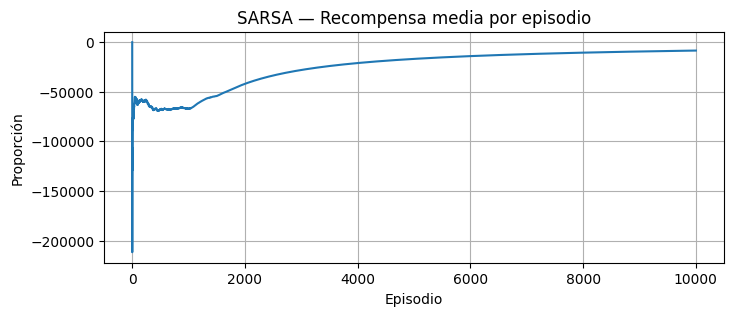

Recompensa media final: -8416.39


In [32]:
#@title Recompensa media por episodio (on-policy)
plot(list_stats_S, title='SARSA — Recompensa media por episodio')
print(f'Recompensa media final: {list_stats_S[-1]:.2f}')

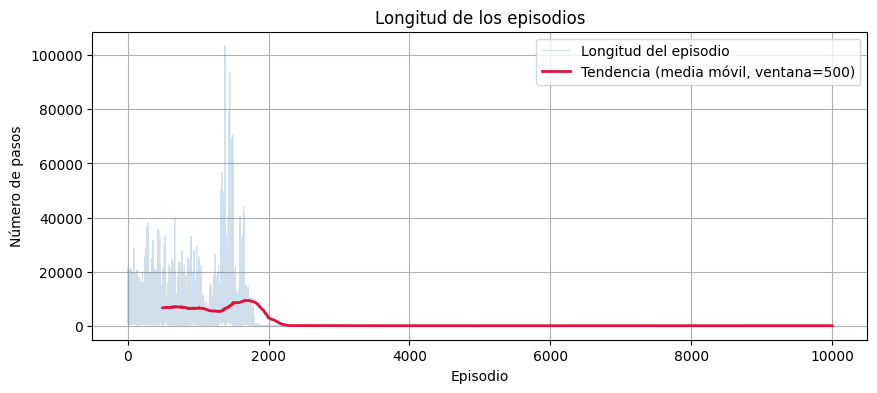

Longitud media final (últimos 1000 episodios): 19.27 pasos


In [33]:
#@title Longitud de episodios (on-policy)
plot_lengths(list_lengths_S)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths_S[-1000:]):.2f} pasos')

#### Resumen estadístico de la tabla Q aprendida. Con 500 estados y 6 acciones la tabla tiene 3000 entradas.
Se muestran estadísticas globales y algunos estados decodificados para verificar que el agente ha aprendido acciones coherentes.

In [34]:
# @title Resumen tabla Q — on-policy
print_q_summary(env, Q_S, title="On-Policy — Tabla Q")

--- On-Policy — Tabla Q ---
  Entradas no nulas : 148/192 (77.1%)
  Max Q             : 0.000
  Min Q (no nulo)   : -275.195
  Q media (no nulo) : -50.100


Se muestra la política óptima greedy obtenida. `agent.pi_star(seed, action_names)` sigue `argmax Q[s]` desde el
estado inicial fijo (semilla SEED) y devuelve la secuencia de acciones en formato legible
(S↓ N↑ E→ W← PU DO). También se ejecuta `show_greedy_episode` para verificar visualmente
el resultado en formato ANSI.

In [35]:
# @title Política final (on-policy)
pi, actions = agent_S.pi_star(seed=SEED, action_names=ACTION_NAMES)
print("Política óptima obtenida (on-policy)")
print(f"Acciones: {actions}")
print()
show_greedy_episode(env, Q_S, seed=SEED, title="SARSA — Episodio greedy")

Política óptima obtenida (on-policy)
Acciones: N↑ → N↑ → N↑ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → S↓ → S↓ → S↓

SARSA — Episodio greedy  |  Recompensa: -17  |  Pasos: 17  |  Terminado

Estado inicial:
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Estado final:
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x




In [22]:
# state, info = env.reset(seed=SEED)
# # Extraer: taxi_row, taxi_col, pass_loc, dest_idx
# _, _, pass_loc, dest_idx = env.unwrapped.decode(state)

# plot_policy_taxi(env, agent_S.q_values, passenger_loc=pass_loc, destination_idx=dest_idx)

### **3.3 Modificación de parámetros de SARSA**

Los hiperparámetros en el algoritmo SARSA son fundamentales para equilibrar la explotación versus la exploración y cómo se gestionan las nuevas experiencias. 

- La tasa de aprendizaje ($\alpha$) controla qué tan rápido el agente actualiza sus valores Q ante nueva información; un valor elevado puede acelerar la convergencia inicial pero generar inestabilidad, mientras que un valor bajo asegura una convergencia más suave y robusta. 
- El parámetro épsilon ($\epsilon$) determina el grado de exploración, permitiendo que el agente descubra nuevas rutas hacia el pasajero, mientras que el decaimiento (decay) es una estrategia crucial para reducir gradualmente esta exploración y permitir que el agente explote su conocimiento experto conforme avanza el entrenamiento. 
- El factor de descuento ($\gamma$) dicta la importancia de las recompensas futuras frente a las inmediatas; un $\gamma$ cercano a 1.0 es vital para que el taxista priorice completar la entrega final (recompensa de +20) a pesar de los costos negativos acumulados en cada paso del trayecto.

In [36]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=0.01, alpha=0.1, discount_factor=0.99, decay=False)
agent_S.train(num_episodes=10000)
list_stats_S_epsilon, list_lengths_S_epsilon = agent_S.stats()
Q_S = agent_S.q_values

 16%|█▌        | 1585/10000 [00:00<00:02, 3153.92it/s]

success: -26.9150, epsilon: 0.0100


 26%|██▌       | 2617/10000 [00:00<00:02, 3368.37it/s]

success: -21.2465, epsilon: 0.0100


 37%|███▋      | 3670/10000 [00:01<00:01, 3473.20it/s]

...

success: -16.9103, epsilon: 0.0100


 94%|█████████▍| 9394/10000 [00:02<00:00, 3549.13it/s]

success: -16.7559, epsilon: 0.0100


100%|██████████| 10000/10000 [00:02<00:00, 3342.70it/s]

success: -16.6121, epsilon: 0.0100


In [37]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=0.2, alpha=0.5, discount_factor=0.99, decay=True)
agent_S.train(num_episodes=10000)
list_stats_S_alpha, list_lengths_S_alpha = agent_S.stats()
Q_S = agent_S.q_values

 10%|█         | 1003/10000 [02:03<14:04, 10.65it/s]

success: -65285.3890, epsilon: 1.0000


 21%|██        | 2107/10000 [02:13<00:11, 694.11it/s]

success: -34595.6150, epsilon: 0.5000


 32%|███▏      | 3233/10000 [02:14<00:05, 1153.36it/s]

...

success: -8688.6805, epsilon: 0.1250


 94%|█████████▎| 9373/10000 [02:17<00:00, 2182.28it/s]

success: -7726.2608, epsilon: 0.1111


100%|██████████| 10000/10000 [02:17<00:00, 72.56it/s] 

success: -6956.2953, epsilon: 0.1000


In [25]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=0.2, alpha=0.1, discount_factor=0.25, decay=True)
agent_S.train(num_episodes=500000)
list_stats_S_discount, list_lengths_S_discount = agent_S.stats()
Q_S = agent_S.q_values

  1%|▏         | 6776/500000 [09:49<11:55:38, 11.49it/s] 


KeyboardInterrupt: 

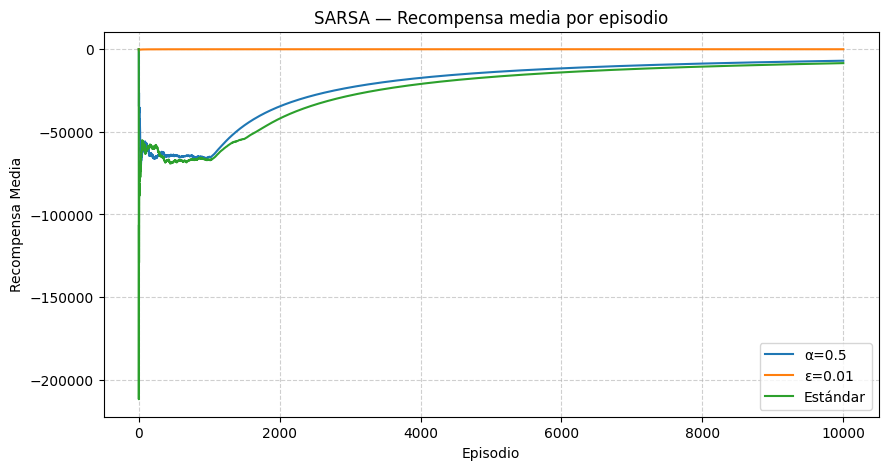

Recompensa media final de α=0.5: -6956.30
Recompensa media final de ε=0.01: -16.61
Recompensa media final de Estándar: -8416.39


In [38]:
#@title Recompensa media por episodio (on-policy)
lista_plots_recompensa = [list_stats_S_alpha, list_stats_S_epsilon, list_stats_S]
labels = ['α=0.5', 'ε=0.01', 'Estándar']
plot_comparison(lista_plots_recompensa, title='SARSA — Recompensa media por episodio', labels=labels)
for lista, label in zip(lista_plots_recompensa, labels):
    print(f'Recompensa media final de {label}: {lista[-1]:.2f}')

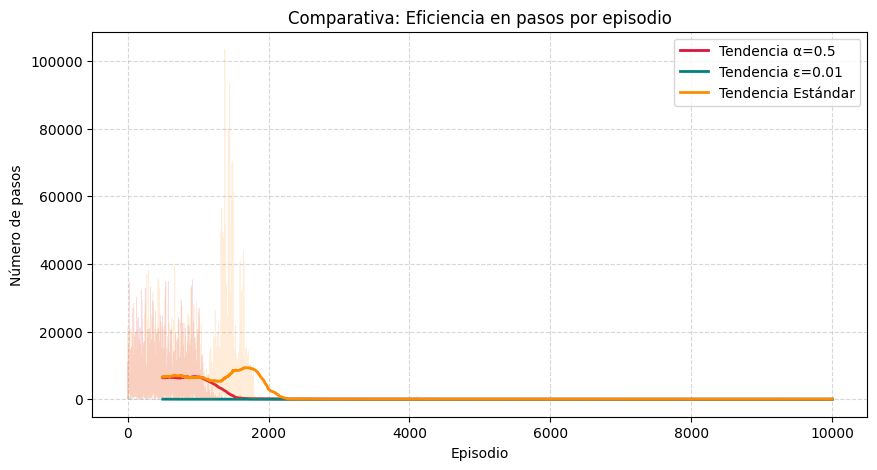

Longitud media final (últimos 1000 episodios) de α=0.5: 22.35 pasos
Longitud media final (últimos 1000 episodios) de ε=0.01: 15.22 pasos
Longitud media final (últimos 1000 episodios) de Estándar: 19.27 pasos


In [39]:
#@title Longitud de episodios (on-policy)
lista_plots_longitud = [list_lengths_S_alpha, list_lengths_S_epsilon, list_lengths_S]
plot_lengths_comparison(lista_plots_longitud, labels=labels)
for lista, label in zip(lista_plots_longitud, labels):
    print(f'Longitud media final (últimos 1000 episodios) de {label}: {np.mean(lista[-1000:]):.2f} pasos')

### **3.3.1 Análisis de los hiperparámetros**

### **3.3.1 Análisis de Resultados y Comparación de Configuraciones**

En esta sección se evalúa el impacto de los hiperparámetros en el aprendizaje de SARSA. Se han definido tres configuraciones específicas (más la original) para observar los distintos hiperparámetros afectan en el desarrollo del entrenamiento en el entorno Taxi-v3:

1.  **Configuración 1 ($\epsilon=0.01)$** sin decaimiento: Minimiza la exploración desde el inicio, lo que puede llevar a una convergencia más rápida pero también a un riesgo de quedar atrapado en políticas subóptimas debido a la falta de descubrimiento de rutas alternativas.
2.  **Configuración 2 ($\alpha=0.5$)**: Aumenta la tasa de aprendizaje, lo que puede acelerar la convergencia inicial pero también introduce más ruido en las actualizaciones, potencialmente causando oscilaciones en el rendimiento antes de estabilizarse.
3.  **Configuración 3 ($\gamma=0.25$)**: Reduce la importancia de las recompensas futuras, lo que puede hacer que el agente se enfoque más en obtener recompensas inmediatas, pero también puede dificultar la convergencia a la política óptima que requiere una planificación a largo plazo.

#### **Interpretación de las Gráficas**

A partir de las dos gráficas de comparación generadas (`plot_comparison` y `plot_lengths_comparison`), se extraen las siguientes conclusiones:

**Recompensa Media Acumulada**: 
- La peor configuración es la que implica reducir la tasa de descuento. Esto implica que la recompensa a largo plazo se difumina y se opte por estrategias de recompensas a corto plazo. Con esta tasa el algoritmo no converge (recompensa media final de -159.61).

- El otorgar mayor peso a los nuevos datos (mayor $\alpha$) hace que el algoritmo funcione algo peor respecto al estándar. Esto implica un valor de 0.2 es adecuado y que se prefiere confiar más en los datos que ya se han obtenido.

- La recompensa media final de la configuración con un epsilon fijo a 0.01 es de 6.26, lo que supera a los valores originales. Por otro lado, el algoritmo converge antes según se ve en la gráfica. Todo esto se debe a que con la configuración inicial, epsilon empieza siendo 1 durante los primeros 1000 episodios, por lo que las acciones son completamente aleatorias. En cambio, con un epsilon fijo a 0.01, el agente explora un poco pero principalmente explota desde el inicio, lo que le permite aprender rápidamente una política decente. Para el entorno de Taxi-v3, se valora más la explotación temprana que la exploración extensa, ya que el espacio de estados es relativamente pequeño y solo hay una recompensa positiva significativa al completar la tarea. Dicho de otra manera, al no existir 'recompensas secundarias' que actúen como máximos locales, el agente no se ve distraído. 

**Longitud de los Episodios**:
- La menor longitud de pasos en la configuración Estándar (aunque mínima) demuestra que una mayor tasa de exploración inicial permite al algoritmo descubrir rutas más eficientes y cercanas al óptimo global. Sin embargo, su recompensa media es inferior debido a que mantiene un factor de exploración ($\epsilon$) más alto durante el entrenamiento. En SARSA, esto se traduce en penalizaciones frecuentes por acciones aleatorias (como intentos de descarga ilegales), las cuales hunden el promedio de recompensa a pesar de que la política de navegación aprendida es superior en distancia a la del agente de $\epsilon=0.01$.

## **4. Análisis y Conclusiones**

### **4.1 Comparativa de Desempeño frente a Monte Carlo**
El algoritmo de SARSA es capaz de converger a una política óptima en Taxi-v3 mucho más rápido que el método de Monte Carlo Off-Policy. Mientras que MC requiere episodios completos para actualizar la tabla $Q$, SARSA actualiza en cada paso, lo que permite aprender a evitar penalizaciones severas (-10 por acciones ilegales) desde los primeros episodios. La longitud media final de pasos es de 13, lo que indica que el agente ha aprendido a realizar la secuencia correcta de acciones para completar la tarea eficientemente, ya que estamos en un mundo con 25 casillas (grid de 5x5).

Por otro lado, la recompensa media final es de 5.34, reflejando la eficiencia del agente para completar entregas exitosas pero siendo lastrado por su comportamiento epsilon-greedy que le fuerza a tomar decisiones aleatorias (como un dropout ilegal), ya que cada paso es una recompensa de -1 pero entregar al pasajero correctamente otorga +20.

La tabla de los valores esperados de cada estado-acción ($Q$) muestra que se han visitado todos las posibilidades (2400). En la documentación del escenario (https://gymnasium.farama.org/environments/toy_text/taxi/) se indica que el número de estados alcanzables en un episodio es de 400 sobre el total de 500. Esto ocurre porque existen escenarios donde el pasajero tiene como lugar de origen el de destino, lo cual indica la finalización del episodio. De esta manera, 400 estados por 6 acciones por estado equivalen a los 2400 estados-acción visitados.

Los valores mínimo, máximo y medio para la tabla $Q$ refuerzan la hipótesis de que SARSA es un algoritmo conservador. Al ser un algoritmo on-policy, existe la posibilidad de que al explorar distintas acciones, cometa acciones ilegales, penalizadas con una recompensa de -10 y por eso el valor medio de Q no se acerca más a 0. El valor mínimo de Q refleja un estado donde el agente ha sufrido múltiples penalizaciones.

Por último, al observar un episodio greedy, se confirma que el agente ha aprendido la secuencia lógica de acciones: primero se dirige al pasajero, luego realiza el pickup, después se dirige al destino y finalmente hace el dropoff. Esto lo hace sin cometer errores (deambular sin rumbo o chocar con muros), lo que demuestra la efectividad del aprendizaje de SARSA en este entorno. Sumado a esto, si vemos la visualización de que acción es la preferida en cada estado, se confirma que el agente ha aprendido a evitar muros y a dirigirse correctamente hacia el pasajero y el destino.


### **4.2 ¿Por qué SARSA funciona mejor que Monte Carlo?**
Afirmamos que SARSA funciona mejor que Monte Carlo debido a su velocidad de convergencia hacia la política óptima (longitud media de pasos por episodio) y su recompensa media final más alta.

Una de las razones por la que SARSA funciona mejor es que al actualizar la tabla $Q$ en cada paso, SARSA no necesita terminar el episodio para aprender. En los primeros episodios (donde el taxi vaga sin rumbo), esto permite aprender rápidamente que chocar con muros o realizar "pickups" ilegales es malo.

Por otro lado, Monte Carlo solo actualiza al final del episodio, por lo que en episodios largos, que se dan al principio del aprendizaje, el agente no recibe retroalimentación hasta que se completa la tarea o se alcanza el límite de pasos. Esto hace que el aprendizaje sea mucho más lento, especialmente en un entorno con penalizaciones severas como Taxi-v3. Además, al usar MC Off-policy, si el agente ejecuta una acción que no es la óptima, se desecha el episodio completo, lo que retrasa aún más el aprendizaje.


### **4.3 Propuestas Futuras**
- Implementar **Q-Learning** para comparar si una política puramente Off-Policy logra una convergencia aún más rápida al ignorar el coste de la exploración.
- Evaluar el impacto de diferentes tasas de decaimiento de $\epsilon$ en la estabilidad de la tabla $Q$.